In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

In [12]:
def f_grad(x):
    return 2*x + 4

In [13]:
def gradient_descent(lr, iterations=100):
    x = 10.0
    path = []
    for _ in range(iterations):
        path.append(x)
        x = x - lr * f_grad(x)
    return path

In [14]:
def plot():
    plt.figure(figsize=(10, 4.5))
    
    path = gradient_descent(0.01)
    plt.plot(path, label="eta = 0.01 (small)")
    plt.legend()
    plt.show()
    
    path = gradient_descent(0.1)
    plt.plot(path, label="eta = 0.1 (optimal)")
    plt.legend()
    plt.show()
    
    path = gradient_descent(1.1)
    plt.plot(path, label="eta = 1.1 (unstable)")
    plt.legend()
    plt.show()

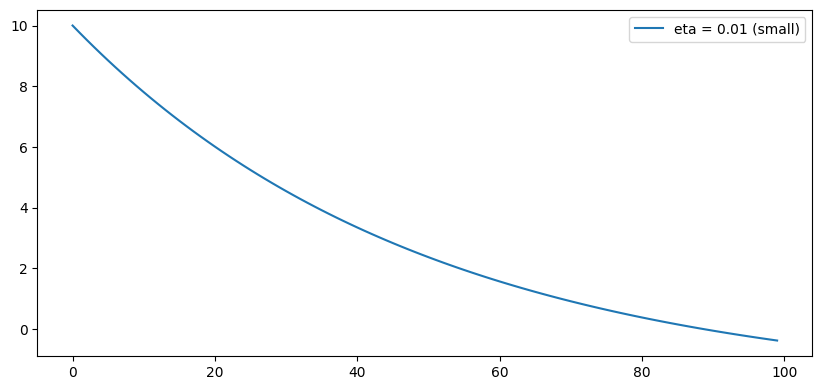

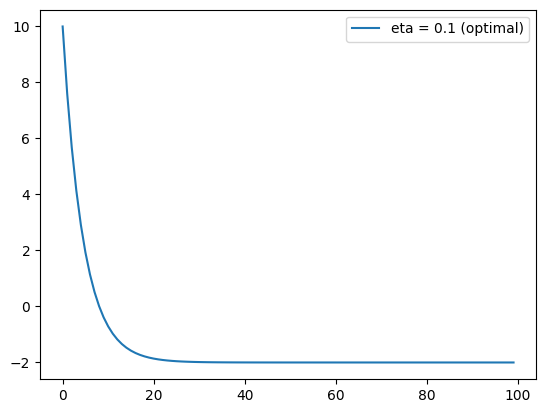

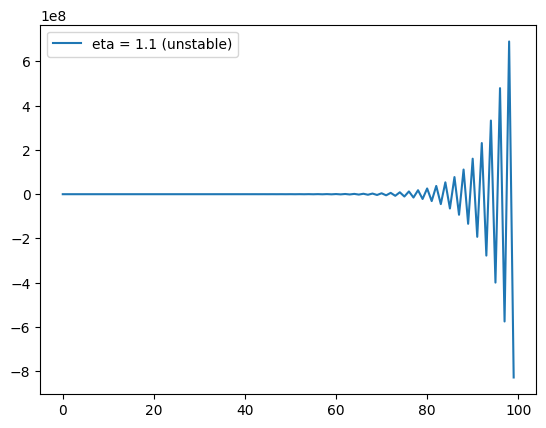

In [15]:
plot()

In [16]:
def loss_fn(x):
    return x**4 - 5*x**2 + 4*x

In [17]:
def run_optimizer(optimizer_class, start_x, lr=0.01, steps=100):
    x = torch.tensor(start_x, requires_grad=True)
    optimizer = optimizer_class([x], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(x)
        loss.backward()
        optimizer.step()

    return x.item()

In [18]:
points = np.linspace(-5, 5, 10)
res1 = []
res2 = []
res3 = []

In [ ]:
for start in points:
    print(f"\nx = {start}")
    a = run_optimizer(torch.optim.SGD, start)
    print("SGD     :", a)
    res1.append(a)
    b = run_optimizer(torch.optim.RMSprop, start)
    print("RMSProp :", b)
    res2.append(b)
    c = run_optimizer(torch.optim.Adam, start)
    print("Adam    :", c)
    res3.append(c)


x = -5.0
SGD     : -1.7523321767936817
RMSProp : -3.41885125910601
Adam    : -4.111014012206789

x = -3.888888888888889
SGD     : -1.75233217679403
RMSProp : -2.4704805235250547
Adam    : -3.042026590313616

x = -2.7777777777777777
SGD     : -1.752332176794035
RMSProp : -1.7991547619547656
Adam    : -2.0504275599922916

x = -1.6666666666666665
SGD     : -1.7523321767940214
RMSProp : -1.7523321767940239
Adam    : -1.7523489753936552

x = -0.5555555555555554
SGD     : -1.7523321767937874
RMSProp : -1.749868827451758
Adam    : -1.5168594333043801

x = 0.5555555555555554
SGD     : 1.3198710232982955
RMSProp : 1.320011733333907
Adam    : 1.334888179911288

x = 1.666666666666667
SGD     : 1.3200138107039165
RMSProp : 1.3200117349390963
Adam    : 1.3181297924243327

x = 2.7777777777777786
SGD     : 1.3200152357829622
RMSProp : 1.6045515926481022
Adam    : 2.004224707475056

x = 3.8888888888888893
SGD     : 1.320014747945132
RMSProp : 2.4343284109295946
Adam    : 3.0344725353649493

x = 5.0
S

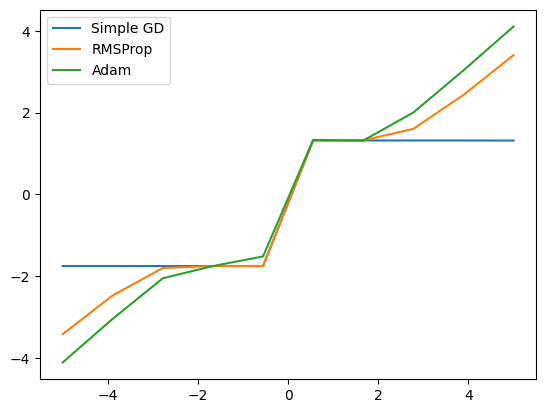

In [20]:
plt.plot(points, res1, label = "Simple GD")
plt.plot(points, res2, label = "RMSProp")
plt.plot(points, res3, label = "Adam")
plt.legend()
plt.show()